In [1]:
from pathlib import Path
from typing import List
import argparse
import sys

from torchtyping import TensorType as TT

from pff import config_dir, data_dir, reports_dir
from pff.config_classes.node_pk_config import NodePKConfig
from pff.data_empirical import (
    load_empirical_json_batches,
    load_empirical_json_batches_as_dm,
    prediction_to_study_jsons,
    load_empirical_hf_batches_as_dm
)
from pff.datasets.aicme_datasets import (
    AICMECompartmentsDataBatch,
    AICMECompartmentsDataModule,
)
from pff.models.amortized_inference.flows_pk import FlowPK
from pff.models.amortized_inference.aicme import AICMEPK
from pff.data_empirical.json_schema import StudyJSON
from pff.utils.plots.databatch_plot import plot_list_list_study_json
from pff.utils.plots.databatch_plot import plot_list_aicme_databatch

In [2]:
from dataclasses import dataclass
from pathlib import Path

@dataclass
class EmpiricalPredictionConfig:
    yaml: Path = Path("experiment_configs/node-pk/base-flow.yaml")
    out: Path = Path("empirical_prediction_plot.png")

# Example usage in a notebook:
args = EmpiricalPredictionConfig(
    yaml=Path(config_dir) / "experiment_configs/node-pk/base-flow.yaml",
    out=Path(reports_dir) / "empirical_prediction_plot.png",
)

# Data generation

In [3]:
# 1) Load configuration ---------------------------------------------------
cfg: NodePKConfig = NodePKConfig.from_yaml(str(args.yaml))

# 2) Build synthetic data module and model -------------------------------
dm = AICMECompartmentsDataModule(cfg)
dm.prepare_data()
dm.setup()


# 3) Pull a batch list from requested split and inspect shapes ----------
synthetic_batch_list: List[AICMECompartmentsDataBatch] = next(iter(dm.train_dataloader()))
empirical_batch_list: List[AICMECompartmentsDataBatch] = load_empirical_hf_batches_as_dm("cesarali/lenuzza-2016", meta_dosing=cfg.dosing, datamodule=dm)
empirical_batch = empirical_batch_list[0]

# each element on the list represents databatches where the held out individual to be "sampled" is permuted

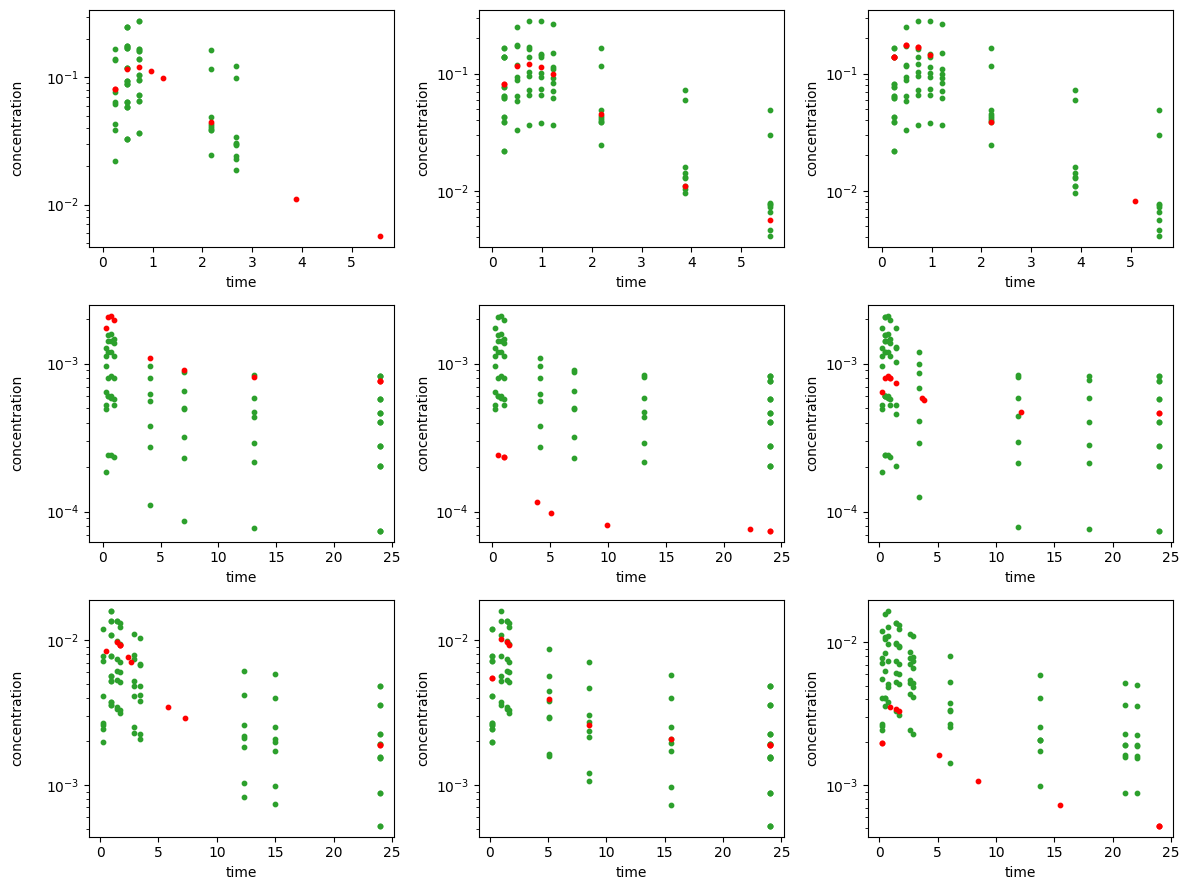

In [4]:
# each column is a different permutation 
# each row is a different "study" i.e. first index of the batch
plot_list_aicme_databatch(synthetic_batch_list)

In [5]:
model = FlowPK(cfg)

In [6]:
cfg

NodePKConfig(name_str='AICMEPK', comet_ai_key=None, experiment_name='aicmepk', hugging_face_token=None, upload_to_hf_hub=False, hf_model_name='AICMEPK_cluster', hf_model_card_path=('hf_model_cards', 'AICME-PK_Readme.md'), tags=['SIM_PRIOR', 'A-0'], experiment_indentifier=None, my_results_path=None, experiment_dir=None, verbose=False, run_index=0, debug_test=True, network=EncoderDecoderNetworkConfig(individual_encoder_name='RNNContextEncoder', time_obs_encoder_hidden_dim=256, time_obs_encoder_output_dim=256, rnn_individual_encoder_number_of_layers=4, individual_encoder_number_of_heads=4, encoder_rnn_hidden_dim=256, input_encoding_hidden_dim=128, zi_latent_dim=256, use_attention=True, decoder_name='TransformerDecoder', decoder_num_layers=4, decoder_attention_layers=2, decoder_hidden_dim=512, decoder_rnn_hidden_dim=256, rnn_decoder_number_of_layers=4, node_step=True, exclusive_node_step=False, cov_proj_dim=16, aggregator_type='attention', aggregator_num_heads=8, prediction_only=True, stud

In [7]:
study_representation = model._study_latent(empirical_batch) # here you have one representation per study

In [8]:
study_representation.shape

torch.Size([18, 256])